In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

In [4]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum().sum()

np.int64(0)

In [7]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [8]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [9]:
df["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


In [10]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [11]:
df = pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [12]:
x = df.drop(columns=["Exited"])
y = df["Exited"]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
st = StandardScaler()

In [17]:
x_train_scaled = st.fit_transform(x_train)

In [18]:
x_test_scaled = st.transform(x_test)

In [19]:
import tensorflow

In [20]:
from tensorflow import keras

In [21]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [22]:
model = Sequential()

In [23]:
model.add(Dense(11,activation="relu",input_dim=11))
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830 (3.25 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 554 (2.17 KB)

In [42]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [43]:
history = model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8673 - loss: 0.3221 - val_accuracy: 0.8606 - val_loss: 0.3316
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8703 - loss: 0.3144 - val_accuracy: 0.8612 - val_loss: 0.3327
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8708 - loss: 0.3193 - val_accuracy: 0.8612 - val_loss: 0.3320
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8721 - loss: 0.3086 - val_accuracy: 0.8625 - val_loss: 0.3326
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8713 - loss: 0.3128 - val_accuracy: 0.8587 - val_loss: 0.3343
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8627 - loss: 0.3239 - val_accuracy: 0.8606 - val_loss: 0.3326
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8652 - loss: 0.3299 - val_accuracy: 0.8612 - val_loss: 0.3317
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8688 - loss: 0.3146 - val_accu

In [29]:
model.layers[0].get_weights()

[array([[ 0.0242524 ,  0.01039565, -0.14926061,  0.25705558,  0.02527124,
         -0.39033502, -0.08879527,  0.00333652,  0.06955054,  0.42842254,
          0.23802085],
        [-0.44249174, -0.01292314,  0.11840778,  0.8289546 ,  0.91999245,
         -0.17188153, -0.09930769,  0.09564482, -0.87948656, -0.38290197,
         -0.02125693],
        [ 0.37249473,  0.06189095, -0.16551289,  0.6033326 ,  0.44483754,
         -0.14085306, -0.2293093 ,  0.52390265,  0.15998572, -0.04581559,
          0.0072472 ],
        [-1.1205229 , -0.39149505,  0.15851392, -0.25903842, -0.3098954 ,
         -0.2563846 , -0.23670115, -0.18320212,  0.02424049, -0.08683207,
          0.38381004],
        [-0.3434178 ,  0.7337756 ,  0.97289366, -0.9542641 ,  0.19749527,
         -0.15594651, -0.95885825,  0.95267534, -0.06394472, -0.5419082 ,
          0.28142768],
        [ 0.14301896,  0.266814  , -0.06619624,  0.05501058,  0.20154445,
         -0.33941132, -0.0276795 , -0.23017374, -0.0657388 ,  0.2975693

In [36]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [37]:
y_te_pred = np.where(y_log>0.5,1,0)

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_test,y_te_pred)

0.8565

In [40]:
accuracy_score(y_train,model.predict(x_train_scaled)>0.5)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.866375

In [44]:
import matplotlib.pyplot as plt

In [45]:
history.history

{'accuracy': [0.8682812452316284,
  0.8673437237739563,
  0.8667187690734863,
  0.8671875,
  0.8675000071525574,
  0.8665624856948853,
  0.8676562309265137,
  0.8671875,
  0.8685937523841858,
  0.8678125143051147,
  0.8668749928474426,
  0.8675000071525574,
  0.8698437213897705,
  0.8687499761581421,
  0.8660937547683716,
  0.8673437237739563,
  0.8717187643051147,
  0.8692187666893005,
  0.867968738079071,
  0.8685937523841858,
  0.8676562309265137,
  0.8685937523841858,
  0.8684375286102295,
  0.8687499761581421,
  0.8676562309265137,
  0.8701562285423279,
  0.8692187666893005,
  0.8681250214576721,
  0.8678125143051147,
  0.8692187666893005,
  0.8700000047683716,
  0.8689062595367432,
  0.8675000071525574,
  0.8676562309265137,
  0.8690624833106995,
  0.8689062595367432,
  0.8696874976158142,
  0.8693749904632568,
  0.867968738079071,
  0.8692187666893005,
  0.8689062595367432,
  0.8690624833106995,
  0.8690624833106995,
  0.8695312738418579,
  0.8684375286102295,
  0.87046873569488

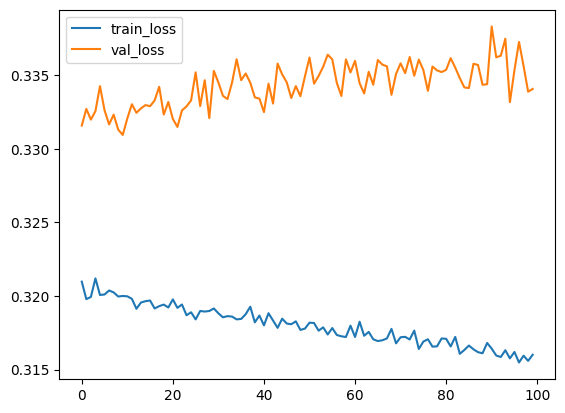

In [53]:
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()
plt.show()

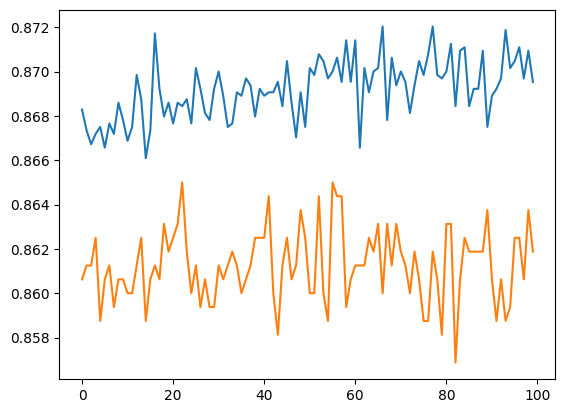

In [52]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"]);